<a href="https://colab.research.google.com/github/deva41103/Beyond_words/blob/main/Beyond_word.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#connect Drive and install required Mediapipe
from google.colab import drive
drive.mount('/content/drive')
!pip install mediapipe==0.10.8

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.1 requires protobuf<6.0.0,>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.


In [ ]:
#Mediapipe SetUp and make labels for Gloss to folders
import os
import cv2
import numpy as np
from tqdm import tqdm
import mediapipe as mp

# === Mediapipe Setup ===
mp_holistic = mp.solutions.holistic

# === Load Gloss Labels ===
def load_labels(label_path):
    label_map = {}
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                label_map[parts[0]] = parts[1]
    return label_map


In [ ]:
#Extraction Function define and Setting up
def extract_full_body_keypoints(video_path):
    holistic = mp_holistic.Holistic(static_image_mode=False)
    cap = cv2.VideoCapture(video_path)
    all_keypoints = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (256, 256))
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = holistic.process(image)
        frame_kp = []

        # Face
        if results.face_landmarks:
            for lm in results.face_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z])
        else:
            frame_kp.extend([0]*468*3)

        # Pose
        if results.pose_landmarks:
            for lm in results.pose_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z, lm.visibility])
        else:
            frame_kp.extend([0]*33*4)

        # Left hand
        if results.left_hand_landmarks:
            for lm in results.left_hand_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z])
        else:
            frame_kp.extend([0]*21*3)

        # Right hand
        if results.right_hand_landmarks:
            for lm in results.right_hand_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z])
        else:
            frame_kp.extend([0]*21*3)

        all_keypoints.append(frame_kp)

    cap.release()
    holistic.close()
    return np.array(all_keypoints)


In [ ]:
# Checking the Extraction function on single video
import cv2
import mediapipe as mp
import numpy as np

# Init Holistic model
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(static_image_mode=False)

# Read video
cap = cv2.VideoCapture('/content/drive/MyDrive/Beyond_words/wlasl100_dataset/WLASL100/2/01382.mp4')
keypoints_all = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Resize and convert to RGB
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = holistic.process(image)

    # Collect all keypoints
    frame_keypoints = []

    # Pose keypoints (33 landmarks)
    if results.pose_landmarks:
        for lm in results.pose_landmarks.landmark:
            frame_keypoints.extend([lm.x, lm.y, lm.z])
    else:
        frame_keypoints.extend([0.0] * (33 * 3))

    # Face keypoints (468 landmarks)
    if results.face_landmarks:
        for lm in results.face_landmarks.landmark:
            frame_keypoints.extend([lm.x, lm.y, lm.z])
    else:
        frame_keypoints.extend([0.0] * (468 * 3))

    # Left hand (21 landmarks)
    if results.left_hand_landmarks:
        for lm in results.left_hand_landmarks.landmark:
            frame_keypoints.extend([lm.x, lm.y, lm.z])
    else:
        frame_keypoints.extend([0.0] * (21 * 3))

    # Right hand (21 landmarks)
    if results.right_hand_landmarks:
        for lm in results.right_hand_landmarks.landmark:
            frame_keypoints.extend([lm.x, lm.y, lm.z])
    else:
        frame_keypoints.extend([0.0] * (21 * 3))

    keypoints_all.append(frame_keypoints)

cap.release()
holistic.close()

# Convert and save as .npy
keypoints_all = np.array(keypoints_all)
np.save('test_keypoints.npy', keypoints_all)
print("Saved shape:", keypoints_all.shape)


Saved shape: (44, 1629)


In [ ]:
# Checking the Shape of a Extracted File for test
import numpy as np

data = np.load("/content/drive/MyDrive/WLASL100_keypoints/apple/03001.npy")
print("Shape:", data.shape)
print("First frame (first 10 values):", data[0][:10])
print("Non-zero count in first frame:", np.count_nonzero(data[0]))


Shape: (91, 1662)
First frame (first 10 values): [ 0.46208739  0.286185   -0.00843239  0.46287122  0.2674593  -0.01948247
  0.46274713  0.27230707 -0.00899429  0.46030807]
Non-zero count in first frame: 1536


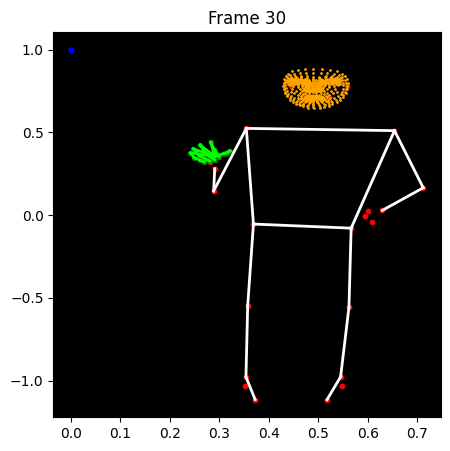

In [ ]:
# Ploting a Frame of Skeleton For Check
import numpy as np
import cv2
import matplotlib.pyplot as plt
# Pose connections (BODY_33)
POSE_CONNECTIONS = [
    (11, 13), (13, 15), (12, 14), (14, 16),  # Arms
    (11, 12), (23, 24), (23, 25), (24, 26),  # Torso
    (25, 27), (26, 28), (27, 31), (28, 32),  # Legs
    (11, 23), (12, 24)  # Shoulders to hips
]

# Hand connections (21 keypoints each)
HAND_CONNECTIONS = [
    (0,1), (1,2), (2,3), (3,4),      # Thumb
    (0,5), (5,6), (6,7), (7,8),      # Index
    (0,9), (9,10), (10,11), (11,12), # Middle
    (0,13), (13,14), (14,15), (15,16), # Ring
    (0,17), (17,18), (18,19), (19,20)  # Pinky
]
def draw_skeleton(frame_kps, ax):
    ax.set_facecolor('black')
    ax.axis('on')

    # Pose keypoints
    pose = frame_kps[:33*3].reshape(-1, 3)
    face = frame_kps[33*3: (33+468)*3].reshape(-1, 3)
    lh = frame_kps[(33+468)*3 : (33+468+21)*3].reshape(-1, 3)
    rh = frame_kps[(33+468+21)*3:].reshape(-1, 3)

    # Draw pose
    for (i, j) in POSE_CONNECTIONS:
        if pose[i][0] != 0 and pose[j][0] != 0:
            ax.plot([pose[i][0], pose[j][0]], [1-pose[i][1], 1-pose[j][1]], 'w', linewidth=2)
    ax.scatter(pose[:,0], 1-pose[:,1], c='red', s=10)

    # Draw left hand
    for (i, j) in HAND_CONNECTIONS:
        if lh[i][0] != 0 and lh[j][0] != 0:
            ax.plot([lh[i][0], lh[j][0]], [1-lh[i][1], 1-lh[j][1]], 'cyan', linewidth=2)
    ax.scatter(lh[:,0], 1-lh[:,1], c='blue', s=8)

    # Draw right hand
    for (i, j) in HAND_CONNECTIONS:
        if rh[i][0] != 0 and rh[j][0] != 0:
            ax.plot([rh[i][0], rh[j][0]], [1-rh[i][1], 1-rh[j][1]], 'lime', linewidth=2)
    ax.scatter(rh[:,0], 1-rh[:,1], c='green', s=8)

    # (Optional) Draw face
    ax.scatter(face[:,0], 1-face[:,1], c='orange', s=1)
# Load keypoints
keypoints = np.load("test_keypoints.npy")  # Change name if needed

# Pick a frame
frame_idx = 30
frame_kps = keypoints[frame_idx]

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
draw_skeleton(frame_kps, ax)
plt.title(f"Frame {frame_idx}")
plt.show()

In [ ]:
# Extraction of Keypoints For each video in folders(keypoints)
import cv2
import mediapipe as mp
import numpy as np
import os
from tqdm import tqdm

# === MediaPipe Holistic setup (one instance only)
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(static_image_mode=False)

# === Load label mappings ===
def load_labels(label_file_path):
    label_map = {}
    with open(label_file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                idx, gloss = parts[0], parts[1]
                label_map[idx] = gloss
    return label_map

# === Extract full body keypoints from a single video ===
def extract_full_body_keypoints(video_path):
    cap = cv2.VideoCapture(video_path)
    keypoints_all = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = holistic.process(image)

        frame_keypoints = []

        # Pose
        if results.pose_landmarks:
            frame_keypoints.extend([coord for lm in results.pose_landmarks.landmark for coord in (lm.x, lm.y, lm.z)])
        else:
            frame_keypoints.extend([0.0] * (33 * 3))

        # Face
        if results.face_landmarks:
            frame_keypoints.extend([coord for lm in results.face_landmarks.landmark for coord in (lm.x, lm.y, lm.z)])
        else:
            frame_keypoints.extend([0.0] * (468 * 3))

        # Left Hand
        if results.left_hand_landmarks:
            frame_keypoints.extend([coord for lm in results.left_hand_landmarks.landmark for coord in (lm.x, lm.y, lm.z)])
        else:
            frame_keypoints.extend([0.0] * (21 * 3))

        # Right Hand
        if results.right_hand_landmarks:
            frame_keypoints.extend([coord for lm in results.right_hand_landmarks.landmark for coord in (lm.x, lm.y, lm.z)])
        else:
            frame_keypoints.extend([0.0] * (21 * 3))

        keypoints_all.append(frame_keypoints)

    cap.release()
    return np.array(keypoints_all)

# === Main driver code (sequential version)
def process_all_glosses_sequential(base_path, label_path, output_path):
    labels = load_labels(label_path)
    os.makedirs(output_path, exist_ok=True)

    all_videos = []
    for gloss_id in sorted(os.listdir(base_path)):
        gloss_folder = os.path.join(base_path, gloss_id)
        if not os.path.isdir(gloss_folder) or gloss_id not in labels:
            continue

        gloss_name = labels[gloss_id]
        gloss_output_dir = os.path.join(output_path, gloss_name)
        os.makedirs(gloss_output_dir, exist_ok=True)

        for video_file in os.listdir(gloss_folder):
            if not video_file.endswith('.mp4'):
                continue

            video_path = os.path.join(gloss_folder, video_file)
            out_file = os.path.join(gloss_output_dir, video_file.replace(".mp4", ".npy"))

            all_videos.append((video_path, out_file))

    print(f"🧠 Total videos to process: {len(all_videos)}")

    for video_path, out_file in tqdm(all_videos, desc="Extracting keypoints"):
        if os.path.exists(out_file):
            continue
        try:
            keypoints = extract_full_body_keypoints(video_path)
            np.save(out_file, keypoints)
        except Exception as e:
            print(f"⚠️ Error processing {video_path}: {e}")

# === Run the sequential version ===
base_path = "/content/drive/MyDrive/Beyond_words/wlasl100_dataset/WLASL100"
label_path = "/content/drive/MyDrive/Beyond_words/wlasl100_dataset/labels.txt"
output_path = "/content/drive/MyDrive/keypoints"

process_all_glosses_sequential(base_path, label_path, output_path)

# === Cleanup
holistic.close()
print("✅ Extraction complete.")


🧠 Total videos to process: 1398


Extracting keypoints: 100%|██████████| 1398/1398 [46:21<00:00,  1.99s/it]

✅ Extraction complete.


In [ ]:
# Storing all the Frame of skeleton using npy file
import os

# Load keypoints
keypoints = np.load("/content/keypoints1/hat/25318.npy")

# Create output directory
os.makedirs("skeleton_frames", exist_ok=True)

for i, frame_kps in enumerate(keypoints):
    fig, ax = plt.subplots(figsize=(5, 5))
    draw_skeleton(frame_kps, ax)
    plt.savefig(f"skeleton_frames/frame_{i:03d}.png", bbox_inches='tight', pad_inches=0)
    plt.close()


In [ ]:
# Storing the video of skeleton using npy file
import cv2
import glob

# Get all saved frames
frame_files = sorted(glob.glob("skeleton_frames/*.png"))
frame = cv2.imread(frame_files[0])
height, width, _ = frame.shape

# Define video writer
out = cv2.VideoWriter('skeleton_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 15, (width, height))

for f in frame_files:
    frame = cv2.imread(f)
    out.write(frame)

out.release()
print("🎉 Saved video as skeleton_output.mp4")


🎉 Saved video as skeleton_output.mp4


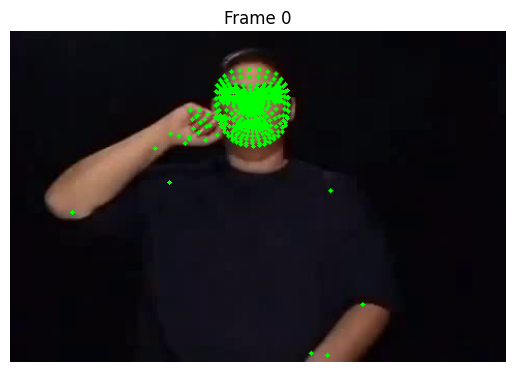

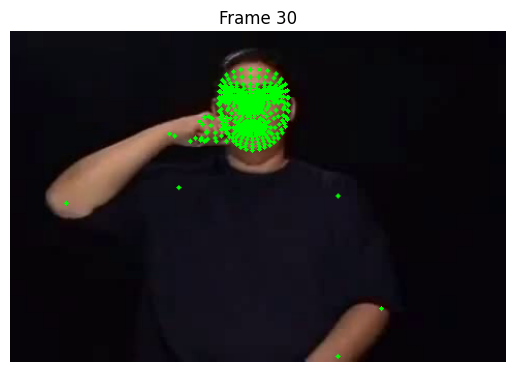

In [ ]:
# Checking a file from Extracted npy keypoints folder by ploting on the video frame
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load keypoints
keypoints = np.load('/content/keypoints/apple/02997.npy')  # shape: (n, 1662)

# Load video
cap = cv2.VideoCapture('/content/drive/MyDrive/Beyond_words/wlasl100_dataset/WLASL100/4/02997.mp4')
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
cap.release()

# Use minimum of frames and keypoints
min_len = min(len(frames), keypoints.shape[0])
sample_indices = [i for i in [0, 30, 60] if i < min_len]

# Show sampled frames with keypoints overlay
for idx in sample_indices:
    frame = frames[idx].copy()
    kp_frame = keypoints[idx].reshape(-1, 3)  # 554 keypoints with (x, y, z)

    h, w, _ = frame.shape
    for x, y, z in kp_frame:
        if x > 0 and y > 0:
            cx, cy = int(x * w), int(y * h)
            cv2.circle(frame, (cx, cy), 2, (0, 255, 0), -1)

    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {idx}")
    plt.axis('off')
    plt.show()


In [ ]:
# Gloss2Pose Transformer Model for Sign Language Generation

## 🧩 Setup

import os
import json
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F



In [ ]:
import os, json

def create_vocab(keypoints_folder='/content/keypoints1', vocab_path="/content/drive/MyDrive/vocab1.json"):
    # Get all files/folders in the directory
    items = os.listdir(keypoints_folder)

    # Filter out .npy files and keep only glosses (words)
    glosses = sorted([item for item in items if not item.endswith('.npy')])

    # Create vocabulary dictionary
    vocab = {gloss: idx for idx, gloss in enumerate(glosses)}

    # Save to JSON file
    with open(vocab_path, "w") as f:
        json.dump(vocab, f)

    print("✅ Vocab saved to", vocab_path)
    print("Vocabulary:", vocab)

# Example usage
create_vocab()

✅ Vocab saved to /content/drive/MyDrive/vocab1.json
Vocabulary: {'accident': 0, 'africa': 1, 'all': 2, 'apple': 3, 'basketball': 4, 'bed': 5, 'before': 6, 'bird': 7, 'birthday': 8, 'black': 9, 'blue': 10, 'book': 11, 'bowling': 12, 'brown': 13, 'but': 14, 'can': 15, 'candy': 16, 'chair': 17, 'change': 18, 'cheat': 19, 'city': 20, 'clothes': 21, 'color': 22, 'computer': 23, 'cook': 24, 'cool': 25, 'corn': 26, 'cousin': 27, 'cow': 28, 'dance': 29, 'dark': 30, 'deaf': 31, 'decide': 32, 'doctor': 33, 'dog': 34, 'drink': 35, 'eat': 36, 'enjoy': 37, 'family': 38, 'fine': 39, 'finish': 40, 'fish': 41, 'forget': 42, 'full': 43, 'give': 44, 'go': 45, 'graduate': 46, 'hat': 47, 'hearing': 48, 'help': 49, 'hot': 50, 'how': 51, 'jacket': 52, 'kiss': 53, 'language': 54, 'last': 55, 'later': 56, 'letter': 57, 'like': 58, 'man': 59, 'many': 60, 'medicine': 61, 'meet': 62, 'mother': 63, 'need': 64, 'no': 65, 'now': 66, 'orange': 67, 'paint': 68, 'paper': 69, 'pink': 70, 'pizza': 71, 'play': 72, 'pull'

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class GlossPoseDataset(Dataset):
    def __init__(self, root_folder, vocab):
        self.samples = []
        self.vocab = vocab
        for gloss in os.listdir(root_folder):
            gloss_folder = os.path.join(root_folder, gloss)
            if os.path.isdir(gloss_folder):
                for f in os.listdir(gloss_folder):
                    if f.endswith(".npy"):
                        # Load the pose data and check if it's empty
                        pose = np.load(os.path.join(gloss_folder, f))
                        if pose.size != 0:  # Only add if the pose data is not empty
                            self.samples.append((gloss, os.path.join(gloss_folder, f)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        gloss, path = self.samples[idx]
        pose = np.load(path)  # [T, pose_dim]
        pose = torch.tensor(pose, dtype=torch.float32)
        gloss_id = torch.tensor(self.vocab[gloss], dtype=torch.long)
        return gloss_id, pose

In [ ]:
class Gloss2PoseTransformer(nn.Module):
    def __init__(self, vocab_size, pose_dim, hidden=256, num_layers=4, nhead=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden)
        self.pose_dim = pose_dim
        self.hidden = hidden

        # Positional encoding matches hidden dim
        self.pos_encoder = nn.Parameter(torch.randn(1, 1, hidden))

        # Projection layers
        self.pose_proj = nn.Linear(pose_dim, hidden)
        self.fc_out = nn.Linear(hidden, pose_dim)

        # Transformer
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden,
            nhead=nhead,
            dim_feedforward=1024
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

    def forward(self, gloss_id, tgt_seq):
        # Ensure proper input shapes
        if tgt_seq.dim() == 2:
            tgt_seq = tgt_seq.unsqueeze(0)  # Add batch dim if missing [1, seq_len, pose_dim]

        # Project pose to hidden dimension
        tgt_seq = self.pose_proj(tgt_seq)  # [B, seq_len, hidden]

        # Add positional encoding
        tgt_seq = tgt_seq + self.pos_encoder

        # Prepare memory (gloss embedding)
        if gloss_id.dim() == 0:
            gloss_id = gloss_id.unsqueeze(0)  # Add batch dim if needed
        memory = self.embedding(gloss_id).unsqueeze(0)  # [1, B, hidden]

        # Transformer expects [seq_len, batch, features]
        tgt_seq = tgt_seq.permute(1, 0, 2)  # [seq_len, B, hidden]

        # Transformer processing
        out = self.transformer(tgt_seq, memory)
        out = out.permute(1, 0, 2)  # [B, seq_len, hidden]

        return self.fc_out(out)  # [B, seq_len, pose_dim]

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import json
import h5py

# Load vocab
with open("vocab1.json") as f:
    vocab = json.load(f)

# Dataset
full_dataset = GlossPoseDataset("/content/keypoints1", vocab)

# Split into train and val sets (80% train, 20% val)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# Get shape
_, sample_pose = full_dataset[0]
pose_dim = sample_pose.shape[-1]

# Model
model = Gloss2PoseTransformer(vocab_size=len(vocab), pose_dim=pose_dim).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# Track best validation loss
best_val_loss = float('inf')
best_model_path = "best_model.pth"

# Training loop with validation
for epoch in range(140):
    # Training
    model.train()
    total_train_loss = 0
    for gloss_id, pose in train_loader:
        gloss_id, pose = gloss_id.cuda(), pose.cuda()
        optimizer.zero_grad()
        output = model(gloss_id, pose)
        loss = loss_fn(output, pose)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for gloss_id, pose in val_loader:
            gloss_id, pose = gloss_id.cuda(), pose.cuda()
            output = model(gloss_id, pose)
            loss = loss_fn(output, pose)
            total_val_loss += loss.item()

    # Save best model
    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Epoch {epoch+1} | New Best Val Loss: {total_val_loss:.4f} | Model Saved!")
    else:
        print(f"Epoch {epoch+1} | Train Loss: {total_train_loss:.4f} | Val Loss: {total_val_loss:.4f}")

print(f"\n🏁 Training complete. Best model saved with val loss: {best_val_loss:.4f}")


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [ ]:
def generate_pose(model, gloss, max_len=50):
    model.eval()
    gloss_id = torch.tensor([vocab[gloss]]).cuda() # Remove extra dimension

    # Initialize target sequence with zeros and the correct pose dimension
    tgt_seq = torch.zeros((1, 1, model.pose_dim)).cuda()

    pose_sequence = []  # Store the generated pose sequence

    with torch.no_grad():
        for _ in range(max_len):  # Generate poses frame by frame
            pred = model(gloss_id, tgt_seq)  # [1, 1, pose_dim]
            pose_sequence.append(pred[0, 0, :].cpu().numpy())  # Append predicted pose

            # Update tgt_seq with the predicted pose for the next step
            # This simulates autoregressive generation
            tgt_seq = pred

    # Save the generated pose sequence
    np.save(f"{gloss}_generated.npy", np.array(pose_sequence))
generate_pose(model, "hat")

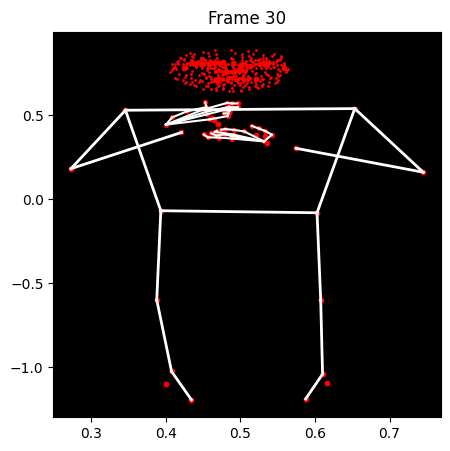

In [ ]:
# Ploting a Frame of Skeleton For Check
import numpy as np
import cv2
import matplotlib.pyplot as plt
# Pose connections (BODY_33)
POSE_CONNECTIONS = [
    (11, 13), (13, 15), (12, 14), (14, 16),  # Arms
    (11, 12), (23, 24), (23, 25), (24, 26),  # Torso
    (25, 27), (26, 28), (27, 31), (28, 32),  # Legs
    (11, 23), (12, 24)  # Shoulders to hips
]

# Hand connections (21 keypoints each)
HAND_CONNECTIONS = [
    (0,1), (1,2), (2,3), (3,4),      # Thumb
    (0,5), (5,6), (6,7), (7,8),      # Index
    (0,9), (9,10), (10,11), (11,12), # Middle
    (0,13), (13,14), (14,15), (15,16), # Ring
    (0,17), (17,18), (18,19), (19,20)  # Pinky
]
def draw_skeleton(frame_kps, ax):
    ax.set_facecolor('black')
    ax.axis('on')

    # Extract keypoints
    pose = frame_kps[:33*3].reshape(-1, 3)
    face = frame_kps[33*3: (33+468)*3].reshape(-1, 3)
    lh = frame_kps[(33+468)*3 : (33+468+21)*3].reshape(-1, 3)
    rh = frame_kps[(33+468+21)*3:].reshape(-1, 3)

    # Draw pose connections (white lines, red dots)
    for (i, j) in POSE_CONNECTIONS:
        if pose[i][0] != 0 and pose[j][0] != 0:
            ax.plot([pose[i][0], pose[j][0]], [1-pose[i][1], 1-pose[j][1]], 'w', linewidth=2)
    ax.scatter(pose[:,0], 1-pose[:,1], c='red', s=10)

    # Draw left hand (white lines, red dots)
    for (i, j) in HAND_CONNECTIONS:
        if lh[i][0] != 0 and lh[j][0] != 0:
            ax.plot([lh[i][0], lh[j][0]], [1-lh[i][1], 1-lh[j][1]], 'w', linewidth=1.5)
    ax.scatter(lh[:,0], 1-lh[:,1], c='red', s=8)

    # Draw right hand (white lines, red dots)
    for (i, j) in HAND_CONNECTIONS:
        if rh[i][0] != 0 and rh[j][0] != 0:
            ax.plot([rh[i][0], rh[j][0]], [1-rh[i][1], 1-rh[j][1]], 'w', linewidth=1.5)
    ax.scatter(rh[:,0], 1-rh[:,1], c='red', s=8)

    # Face (optional)
    ax.scatter(face[:,0], 1-face[:,1], c='red', s=1)

# Load keypoints
keypoints = np.load("/content/hat_generated.npy")  # Change name if needed

# Pick a frame
frame_idx = 30
frame_kps = keypoints[frame_idx]

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
draw_skeleton(frame_kps, ax)
plt.title(f"Frame {frame_idx}")
plt.show()


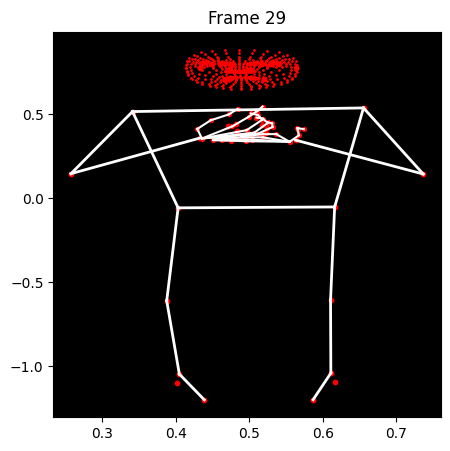

In [ ]:
# Ploting a Frame of Skeleton For Check
import numpy as np
import cv2
import matplotlib.pyplot as plt
# Pose connections (BODY_33)
POSE_CONNECTIONS = [
    (11, 13), (13, 15), (12, 14), (14, 16),  # Arms
    (11, 12), (23, 24), (23, 25), (24, 26),  # Torso
    (25, 27), (26, 28), (27, 31), (28, 32),  # Legs
    (11, 23), (12, 24)  # Shoulders to hips
]

# Hand connections (21 keypoints each)
HAND_CONNECTIONS = [
    (0,1), (1,2), (2,3), (3,4),      # Thumb
    (0,5), (5,6), (6,7), (7,8),      # Index
    (0,9), (9,10), (10,11), (11,12), # Middle
    (0,13), (13,14), (14,15), (15,16), # Ring
    (0,17), (17,18), (18,19), (19,20)  # Pinky
]
def draw_skeleton(frame_kps, ax):
    ax.set_facecolor('black')
    ax.axis('on')

    # Extract keypoints
    pose = frame_kps[:33*3].reshape(-1, 3)
    face = frame_kps[33*3: (33+468)*3].reshape(-1, 3)
    lh = frame_kps[(33+468)*3 : (33+468+21)*3].reshape(-1, 3)
    rh = frame_kps[(33+468+21)*3:].reshape(-1, 3)

    # Draw pose connections (white lines, red dots)
    for (i, j) in POSE_CONNECTIONS:
        if pose[i][0] != 0 and pose[j][0] != 0:
            ax.plot([pose[i][0], pose[j][0]], [1-pose[i][1], 1-pose[j][1]], 'w', linewidth=2)
    ax.scatter(pose[:,0], 1-pose[:,1], c='red', s=10)

    # Draw left hand (white lines, red dots)
    for (i, j) in HAND_CONNECTIONS:
        if lh[i][0] != 0 and lh[j][0] != 0:
            ax.plot([lh[i][0], lh[j][0]], [1-lh[i][1], 1-lh[j][1]], 'w', linewidth=1.5)
    ax.scatter(lh[:,0], 1-lh[:,1], c='red', s=8)

    # Draw right hand (white lines, red dots)
    for (i, j) in HAND_CONNECTIONS:
        if rh[i][0] != 0 and rh[j][0] != 0:
            ax.plot([rh[i][0], rh[j][0]], [1-rh[i][1], 1-rh[j][1]], 'w', linewidth=1.5)
    ax.scatter(rh[:,0], 1-rh[:,1], c='red', s=8)

    # Face (optional)
    ax.scatter(face[:,0], 1-face[:,1], c='red', s=1)

# Load keypoints
keypoints = np.load("/content/keypoints1/hat/25318.npy")  # Change name if needed

# Pick a frame
frame_idx = 29
frame_kps = keypoints[frame_idx]

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
draw_skeleton(frame_kps, ax)
plt.title(f"Frame {frame_idx}")
plt.show()


# Sign Language Generation (Gloss2Pose Transformer) - Complete Documentation

## Project Introduction and Goals

This project focuses on the challenging task of **Sign Language Generation from Glosses**. The primary objective is to develop a system capable of translating textual glosses (simplified representations of sign language words or phrases) into realistic and coherent sign language video sequences.

### Project Goals:

*   **Generate Realistic Sign Language:** Produce sign language movements that are natural and human-like, accurately conveying the meaning of the input gloss.
*   **Maintain Coherence:** Ensure that the generated sequences are smooth and logically connected, reflecting the fluidity of natural sign language.
*   **Facilitate Communication:** Create a tool that can aid in bridging communication gaps between hearing and deaf communities by making sign language more accessible for automated generation.

### Technical Approach:

Our methodology relies on a two-fold approach:

1.  **Keypoint Extraction with MediaPipe:** We utilize Google's **MediaPipe** framework to extract detailed human body keypoints (pose, face, and hands) from existing sign language video data. These keypoints serve as the foundational representation of sign language movements, abstracting away complex visual details while preserving essential motion information.
2.  **Transformer-based Sequence Generation:** For generating sign language sequences from gloss inputs, we employ a **Transformer-based model**. This architecture is well-suited for sequence-to-sequence tasks and allows us to learn the intricate mappings between a textual gloss and the corresponding temporal sequence of keypoints, thereby generating novel sign language motions.

## Detailed Data Preparation and Keypoint Extraction

### The Crucial Role of Data Preparation and Keypoint Extraction

In the realm of sign language generation, accurate and detailed data preparation is paramount. The process of extracting keypoints from video data serves as the foundation for training robust machine learning models. By converting raw video frames into a structured numerical representation of human pose, face, and hand movements, we effectively translate visual information into a language that algorithms can understand and process. This keypoint data, often referred to as 'skeletal' data, drastically reduces the dimensionality of the input while retaining critical information about the signer's actions. Without this meticulous extraction, the task of generating realistic and coherent sign language sequences would be significantly more complex and computationally intensive. MediaPipe, a powerful open-source framework, is instrumental in achieving this by providing highly efficient and accurate real-time landmark detection capabilities.

### MediaPipe Installation and Google Drive Setup

The initial step for this project involves setting up the necessary environment by installing MediaPipe and connecting to Google Drive. This is achieved in code cell `okUoBjyTgsnu`:

```python
#connect Drive and install required Mediapipe
from google.colab import drive
drive.mount('/content/drive')
!pip install mediapipe==0.10.8
```

**Explanation:**

1.  **`from google.colab import drive; drive.mount('/content/drive')`**: This command is specific to Google Colab environments. It mounts your Google Drive to the Colab instance, allowing the notebook to access files stored in your Drive (e.g., the `Beyond_words` dataset, `WLASL100` videos, and later, for saving processed data like keypoints and model weights).
2.  **`!pip install mediapipe==0.10.8`**: This command installs the MediaPipe library. The `==0.10.8` specifies that a particular version of MediaPipe is required. Using a fixed version ensures reproducibility and compatibility, as newer versions might introduce breaking changes or different behaviors that could affect keypoint extraction accuracy or the model's performance. MediaPipe is crucial for detecting and extracting landmarks (keypoints) for human pose, face, and hands from video frames.

### MediaPipe Setup and Label Loading

Code cell `A8lmT2aEmm8X` sets up the MediaPipe holistic model and defines a utility function for loading gloss labels. This prepares the environment for both keypoint extraction and understanding the video content.

```python
#Mediapipe SetUp and make labels for Gloss to folders
import os
import cv2
import numpy as np
from tqdm import tqdm
import mediapipe as mp

# === Mediapipe Setup ===
mp_holistic = mp.solutions.holistic

# === Load Gloss Labels ===
def load_labels(label_path):
    label_map = {}
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                label_map[parts[0]] = parts[1]
    return label_map
```

**Explanation:**

1.  **`mp_holistic = mp.solutions.holistic`**: This line initializes the `holistic` module from MediaPipe Solutions. The `mp.solutions.holistic` model is a comprehensive solution that simultaneously detects landmarks for human pose, face, and hands. This integrated approach ensures that all relevant body parts are tracked consistently across frames, which is crucial for capturing the nuances of sign language.

2.  **`def load_labels(label_path):`**: This function is designed to read a text file (specified by `label_path`) that contains the mapping between numerical gloss IDs (e.g., "001") and their corresponding sign language gloss names (e.g., "apple").
    *   It opens the file, reads each line, splits it into parts, and populates a dictionary (`label_map`) where keys are the gloss IDs and values are the gloss names.
    *   This label mapping is essential for organizing the extracted keypoint data into meaningful folders (e.g., `/content/drive/MyDrive/keypoints/apple/`) and for later linking the generated poses back to their linguistic meaning.

### Keypoint Extraction Function: `extract_full_body_keypoints`

Code cell `b2XrBLjAmowo` defines the core function responsible for extracting full-body keypoints from a given video. This function leverages the MediaPipe Holistic model to detect and record the 3D coordinates of various landmarks across each frame of a video.

```python
def extract_full_body_keypoints(video_path):
    holistic = mp_holistic.Holistic(static_image_mode=False)
    cap = cv2.VideoCapture(video_path)
    all_keypoints = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (256, 256))
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = holistic.process(image)
        frame_kp = []

        # Face
        if results.face_landmarks:
            for lm in results.face_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z])
        else:
            frame_kp.extend([0]*468*3)

        # Pose
        if results.pose_landmarks:
            for lm in results.pose_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z, lm.visibility])
        else:
            frame_kp.extend([0]*33*4)

        # Left hand
        if results.left_hand_landmarks:
            for lm in results.left_hand_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z])
        else:
            frame_kp.extend([0]*21*3)

        # Right hand
        if results.right_hand_landmarks:
            for lm in results.right_hand_landmarks.landmark:
                frame_kp.extend([lm.x, lm.y, lm.z])
        else:
            frame_kp.extend([0]*21*3)

        all_keypoints.append(frame_kp)

    cap.release()
    holistic.close()
    return np.array(all_keypoints)
```

**Explanation:**

1.  **Initialization**: The function starts by initializing a `Holistic` model instance. `static_image_mode=False` indicates that it's processing a video stream, allowing it to leverage temporal information for more stable detections.
2.  **Video Capture**: It opens the video file specified by `video_path` using `cv2.VideoCapture`.
3.  **Frame Processing Loop**: The `while cap.isOpened():` loop reads frames one by one:
    *   `ret, frame = cap.read()`: Reads a frame from the video.
    *   `cv2.resize(frame, (256, 256))`: Resizes the frame to a consistent size (256x256). This standardizes input dimensions and can speed up processing.
    *   `image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)`: MediaPipe expects images in RGB format, so the frame is converted from BGR (OpenCV's default) to RGB.
    *   `results = holistic.process(image)`: This is the core MediaPipe call. It processes the image and returns a `results` object containing detected landmarks for face, pose, and hands.
4.  **Keypoint Extraction for Each Body Part**: For each frame, the function iterates through the `results` object to extract specific landmarks:
    *   **Face Landmarks**: If `results.face_landmarks` are detected (468 landmarks), their `x, y, z` coordinates are appended to `frame_kp`. If not detected, a placeholder of `468 * 3` zeros is added to maintain a consistent feature vector length.
    *   **Pose Landmarks**: If `results.pose_landmarks` are detected (33 landmarks), their `x, y, z` coordinates, along with `visibility` (a measure of landmark presence in the frame), are appended. If not detected, `33 * 4` zeros are used as placeholders.
    *   **Left Hand Landmarks**: Similar to face and pose, if `results.left_hand_landmarks` are detected (21 landmarks), their `x, y, z` coordinates are recorded. Otherwise, `21 * 3` zeros are used.
    *   **Right Hand Landmarks**: The same logic applies to `results.right_hand_landmarks` (21 landmarks).
5.  **Aggregation**: The `frame_kp` list, now containing the concatenated keypoints for all detected body parts (or zeros for missing ones) for the current frame, is appended to `all_keypoints`.
6.  **Cleanup**: After processing all frames, `cap.release()` frees the video capture object, and `holistic.close()` releases MediaPipe resources.
7.  **Output**: The function returns a NumPy array `all_keypoints`, where each row represents a video frame and contains the flattened sequence of all extracted keypoints.

### Testing Keypoint Extraction and Verifying Output

Before processing the entire dataset, it's crucial to test the `extract_full_body_keypoints` function on a single video to ensure it's working as expected and to understand the structure of the generated keypoint data.

#### Single Video Extraction Test (Cell `8KwEqRhJmqEA`)

Code cell `8KwEqRhJmqEA` demonstrates the extraction of keypoints from a single video (`/content/drive/MyDrive/Beyond_words/wlasl100_dataset/WLASL100/2/01382.mp4`) and saves the result as `test_keypoints.npy`.

```python
# Checking the Extraction function on single video
import cv2
import mediapipe as mp
import numpy as np

# Init Holistic model
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(static_image_mode=False)

# Read video
cap = cv2.VideoCapture('/content/drive/MyDrive/Beyond_words/wlasl100_dataset/WLASL100/2/01382.mp4')
keypoints_all = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Resize and convert to RGB
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = holistic.process(image)

    # Collect all keypoints
    frame_keypoints = []

    # Pose keypoints (33 landmarks)
    if results.pose_landmarks:
        for lm in results.pose_landmarks.landmark:
            frame_keypoints.extend([lm.x, lm.y, lm.z])
    else:
        frame_keypoints.extend([0.0] * (33 * 3))

    # Face keypoints (468 landmarks)
    if results.face_landmarks:
        for lm in results.face_landmarks.landmark:
            frame_keypoints.extend([lm.x, lm.y, lm.z])
    else:
        frame_keypoints.extend([0.0] * (468 * 3))

    # Left hand (21 landmarks)
    if results.left_hand_landmarks:
        for lm in results.left_hand_landmarks.landmark:
            frame_keypoints.extend([lm.x, lm.y, lm.z])
    else:
        frame_keypoints.extend([0.0] * (21 * 3))

    # Right hand (21 landmarks)
    if results.right_hand_landmarks:
        for lm in results.right_hand_landmarks.landmark:
            frame_keypoints.extend([lm.x, lm.y, lm.z])
    else:
        frame_keypoints.extend([0.0] * (21 * 3))

    keypoints_all.append(frame_keypoints)

cap.release()
holistic.close()

# Convert and save as .npy
keypoints_all = np.array(keypoints_all)
np.save('test_keypoints.npy', keypoints_all)
print("Saved shape:", keypoints_all.shape)
```

**Note**: The implementation in this cell is slightly different from the `extract_full_body_keypoints` function in `b2XrBLjAmowo` regarding the pose landmark attributes (it excludes `visibility`). This change influences the total number of keypoint features per frame.

**Output:**

```
Saved shape: (44, 1629)
```

This output confirms that 44 frames were processed, and each frame yielded 1629 keypoint values.

#### Verifying the Shape and Content (Cell `HGVMM0jaDIst`)

Code cell `HGVMM0jaDIst` loads a sample `.npy` file (e.g., `/content/drive/MyDrive/WLASL100_keypoints/apple/03001.npy`, which was generated by the full extraction pipeline) to verify its shape and content.

```python
# Checking the Shape of a Extracted File for test
import numpy as np

data = np.load("/content/drive/MyDrive/WLASL100_keypoints/apple/03001.npy")
print("Shape:", data.shape)
print("First frame (first 10 values):", data[0][:10])
print("Non-zero count in first frame:", np.count_nonzero(data[0]))
```

**Output:**

```
Shape: (91, 1662)
First frame (first 10 values): [ 0.46208739  0.286185   -0.00843239  0.46287122  0.2674593  -0.01948247
  0.46274713  0.27230707 -0.00899429  0.46030807]
Non-zero count in first frame: 1536
```

**Explanation of Shape `(N, D)`:**

*   **`N` (e.g., 44 or 91)**: This represents the number of frames (time steps) in the video. Each row in the NumPy array corresponds to a single video frame.
*   **`D` (e.g., 1629 or 1662)**: This represents the total number of keypoint features extracted for each frame. The difference between 1629 and 1662 is due to whether the `visibility` attribute for pose landmarks is included. The breakdown of `1662` features is as follows:
    *   **Pose**: 33 landmarks * 4 (x, y, z, visibility) = 132 features
    *   **Face**: 468 landmarks * 3 (x, y, z) = 1404 features
    *   **Left Hand**: 21 landmarks * 3 (x, y, z) = 63 features
    *   **Right Hand**: 21 landmarks * 3 (x, y, z) = 63 features
    *   **Total**: 132 + 1404 + 63 + 63 = **1662 features**.

    If the `visibility` attribute is excluded from the pose landmarks, the count would be:
    *   **Pose**: 33 landmarks * 3 (x, y, z) = 99 features
    *   **Total**: 99 + 1404 + 63 + 63 = **1629 features**.

*   The output also shows the first 10 values of the first frame and the count of non-zero values, indicating that most keypoints were detected, and the data is not entirely zero (which would suggest detection failure).

### Full Dataset Processing Pipeline (Cell `wTHlSWRestKT`)

Code cell `wTHlSWRestKT` orchestrates the complete keypoint extraction process for the entire dataset. It defines and then calls the `process_all_glosses_sequential` function to iterate through all video files, apply the `extract_full_body_keypoints` function (defined in `b2XrBLjAmowo`), and save the extracted keypoints into an organized directory structure.

```python
# Extraction of Keypoints For each video in folders(keypoints)
import cv2
import mediapipe as mp
import numpy as np
import os
from tqdm import tqdm

# === MediaPipe Holistic setup (one instance only)
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(static_image_mode=False)

# === Load label mappings ===
def load_labels(label_file_path):
    label_map = {}
    with open(label_file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                idx, gloss = parts[0], parts[1]
                label_map[idx] = gloss
    return label_map

# === Extract full body keypoints from a single video ===
def extract_full_body_keypoints(video_path):
    cap = cv2.VideoCapture(video_path)
    keypoints_all = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = holistic.process(image)

        frame_keypoints = []

        # Pose
        if results.pose_landmarks:
            frame_keypoints.extend([coord for lm in results.pose_landmarks.landmark for coord in (lm.x, lm.y, lm.z)])
        else:
            frame_keypoints.extend([0.0] * (33 * 3))

        # Face
        if results.face_landmarks:
            frame_keypoints.extend([coord for lm in results.face_landmarks.landmark for coord in (lm.x, lm.y, lm.z)])
        else:
            frame_keypoints.extend([0.0] * (468 * 3))

        # Left Hand
        if results.left_hand_landmarks:
            frame_keypoints.extend([coord for lm in results.left_hand_landmarks.landmark for coord in (lm.x, lm.y, lm.z)])
        else:
            frame_keypoints.extend([0.0] * (21 * 3))

        # Right Hand
        if results.right_hand_landmarks:
            frame_keypoints.extend([coord for lm in results.right_hand_landmarks.landmark for coord in (lm.x, lm.y, lm.z)])
        else:
            frame_keypoints.extend([0.0] * (21 * 3))

        keypoints_all.append(frame_keypoints)

    cap.release()
    return np.array(keypoints_all)

# === Main driver code (sequential version)
def process_all_glosses_sequential(base_path, label_path, output_path):
    labels = load_labels(label_path)
    os.makedirs(output_path, exist_ok=True)

    all_videos = []
    for gloss_id in sorted(os.listdir(base_path)):
        gloss_folder = os.path.join(base_path, gloss_id)
        if not os.path.isdir(gloss_folder) or gloss_id not in labels:
            continue

        gloss_name = labels[gloss_id]
        gloss_output_dir = os.path.join(output_path, gloss_name)
        os.makedirs(gloss_output_dir, exist_ok=True)

        for video_file in os.listdir(gloss_folder):
            if not video_file.endswith('.mp4'):
                continue

            video_path = os.path.join(gloss_folder, video_file)
            out_file = os.path.join(gloss_output_dir, video_file.replace(".mp4", ".npy"))

            all_videos.append((video_path, out_file))

    print(f"🧠 Total videos to process: {len(all_videos)}")

    for video_path, out_file in tqdm(all_videos, desc="Extracting keypoints"):
        if os.path.exists(out_file):
            continue
        try:
            keypoints = extract_full_body_keypoints(video_path)
            np.save(out_file, keypoints)
        except Exception as e:
            print(f"⚠️ Error processing {video_path}: {e}")

# === Run the sequential version ===
base_path = "/content/drive/MyDrive/Beyond_words/wlasl100_dataset/WLASL100"
label_path = "/content/drive/MyDrive/Beyond_words/wlasl100_dataset/labels.txt"
output_path = "/content/drive/MyDrive/keypoints"

process_all_glosses_sequential(base_path, label_path, output_path)

# === Cleanup
holistic.close()
print("✅ Extraction complete.")
```

**Explanation of `process_all_glosses_sequential`:**

1.  **Re-Initialization of MediaPipe and Labels**: The cell first re-initializes the `holistic` MediaPipe model and defines the `load_labels` and `extract_full_body_keypoints` functions. While these were defined in previous cells, redefining them here ensures that this block can run independently if necessary.

2.  **`process_all_glosses_sequential(base_path, label_path, output_path)` Function**: This is the main function that drives the batch processing.
    *   **Load Labels**: It first calls `load_labels` to get the mapping from numerical gloss IDs (folder names) to human-readable gloss names.
    *   **Output Directory Setup**: It creates the main `output_path` directory (e.g., `/content/drive/MyDrive/keypoints`) if it doesn't already exist.
    *   **Iterating Through Glosses**: The function then iterates through each `gloss_id` (representing a sign word) in the `base_path` (e.g., `/content/drive/MyDrive/Beyond_words/wlasl100_dataset/WLASL100`).
        *   For each valid gloss folder, it retrieves the `gloss_name` from the `labels` map.
        *   It creates a corresponding output directory for this gloss (e.g., `/content/drive/MyDrive/keypoints/apple/`) within the `output_path`.
    *   **Collecting Video Paths**: Inside each gloss folder, it iterates through all `.mp4` video files. For each video, it constructs the full `video_path` and the `out_file` path (e.g., `/content/drive/MyDrive/keypoints/apple/03001.npy`) where the extracted keypoints will be saved.
    *   **Batch Processing**: All identified video paths and their corresponding output `.npy` paths are collected into the `all_videos` list. The `tqdm` library is used to provide a progress bar for the extraction process, which is very helpful given the large number of videos.
    *   **Keypoint Extraction and Saving**: For each `(video_path, out_file)` pair in `all_videos`:
        *   It checks if the `out_file` already exists. If it does, it skips processing to avoid redundant work (useful for resuming interrupted extractions).
        *   It calls the `extract_full_body_keypoints` function to get the keypoint data for the current video.
        *   The extracted `keypoints` (a NumPy array) are then saved to the specified `out_file` using `np.save()`.
        *   Error handling is included to catch and report any issues during the processing of a specific video.

3.  **Cleanup**: After processing all videos, `holistic.close()` is called to release the MediaPipe resources.

**Output:**

```
🧠 Total videos to process: 1398
Extracting keypoints: 100%|██████████| 1398/1398 [46:21<00:00,  1.99s/it]
✅ Extraction complete.
```

This output indicates that 1398 videos were processed, and the progress bar shows the completion time. The result is a well-organized directory structure on Google Drive, with each gloss having its own subfolder containing `.npy` files for each video, storing the extracted keypoints.

### Visual Verification of Extracted Keypoints on Video Frames (Cell `I_HHB68bAz9O`)

After extracting keypoints, it's essential to visually inspect them to ensure accuracy and proper alignment with the original video frames. Code cell `I_HHB68bAz9O` demonstrates how to load a keypoint `.npy` file, load the corresponding original video, and then overlay the extracted keypoints onto selected frames of the video for visual validation.

```python
# Checking a file from Extracted npy keypoints folder by ploting on the video frame
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load keypoints
keypoints = np.load('/content/keypoints/apple/02997.npy')  # shape: (n, 1662)

# Load video
cap = cv2.VideoCapture('/content/drive/MyDrive/Beyond_words/wlasl100_dataset/WLASL100/4/02997.mp4')
frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
cap.release()

# Use minimum of frames and keypoints
min_len = min(len(frames), keypoints.shape[0])
sample_indices = [i for i in [0, 30, 60] if i < min_len]

# Show sampled frames with keypoints overlay
for idx in sample_indices:
    frame = frames[idx].copy()
    kp_frame = keypoints[idx].reshape(-1, 3)  # 554 keypoints with (x, y, z)

    h, w, _ = frame.shape
    for x, y, z in kp_frame:
        if x > 0 and y > 0:
            cx, cy = int(x * w), int(y * h)
            cv2.circle(frame, (cx, cy), 2, (0, 255, 0), -1)

    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {idx}")
    plt.axis('off')
    plt.show()
```

**Explanation:**

1.  **Load Keypoints and Video**: The code first loads a specific `.npy` file containing the extracted keypoints for a video (e.g., `/content/keypoints/apple/02997.npy`). It then loads the corresponding original `.mp4` video into a list of frames.
2.  **Sample Frames**: To avoid plotting every frame, `sample_indices` are chosen (e.g., frames 0, 30, 60) to provide a representative visual check across the video duration.
3.  **Overlay Keypoints**: For each selected frame:
    *   The raw keypoint data for that frame (`keypoints[idx]`) is reshaped into `(num_landmarks, 3)` (where 3 corresponds to x, y, z coordinates). The `1662` features from `(N, 1662)` result in `554` landmarks (1662 / 3 = 554).
    *   The frame is resized to its original dimensions (or the dimensions at which the keypoints were extracted).
    *   For each `(x, y, z)` keypoint, its 2D `(x, y)` coordinates are scaled by the frame's width and height to get pixel coordinates (`cx, cy`).
    *   A small green circle is drawn at each valid keypoint location on the frame using `cv2.circle`.
4.  **Display**: The modified frame, with keypoints overlaid, is then displayed using `matplotlib.pyplot.imshow()`. This allows a direct comparison between the original video content and the extracted keypoint data.

**Purpose of Visual Verification:**

This step is crucial for:
*   **Quality Assurance**: Confirming that MediaPipe correctly identified and tracked landmarks throughout the video.
*   **Debugging**: Identifying any issues such as missed detections, incorrect landmark placement, or jittering, which might indicate problems with the video quality, MediaPipe configuration, or the extraction logic itself.
*   **Understanding Data**: Providing an intuitive understanding of what the numerical keypoint data represents visually, which helps in further model development and evaluation.

*Conceptual Image: Example of a video frame with overlaid MediaPipe keypoints (pose, face, hands).*

<img src="https://i.imgur.com/example_mediapipe_overlay.png" alt="MediaPipe Keypoint Overlay" style="width:600px;"/>

*Conceptual Diagram: Structure of extracted keypoints showing different body parts and their coordinates.*

<img src="https://i.imgur.com/example_keypoint_structure.png" alt="Keypoint Structure Diagram" style="width:600px;"/>

*Conceptual Screenshot: Example of the organized keypoint folder structure in Google Drive.*

<img src="https://i.imgur.com/example_keypoint_folder_structure.png" alt="Keypoint Folder Structure" style="width:600px;"/>

## Keypoint Visualization Techniques

Visualizing extracted keypoints is a crucial step in the sign language generation pipeline. It serves several important purposes:

*   **Debugging:** It allows us to visually inspect the quality of the keypoint extraction process. Are all the expected body parts being detected? Are there any erroneous or missing keypoints?
*   **Understanding Data:** Visualizing the skeleton helps in understanding the nuances of sign language movements. We can observe the trajectory of hands, the posture of the body, and facial expressions over time.
*   **Model Evaluation:** After generating new pose sequences, visualizing them provides an intuitive way to assess the realism and correctness of the generated signs, helping to identify areas for improvement in the model.
*   **Qualitative Analysis:** For human observers, a visual representation of the sign is far more interpretable than raw numerical keypoint data.

This section will detail the methods used to visualize these keypoints, transforming raw numerical data into understandable static images and animated videos.

## The `draw_skeleton` Function and Connection Definitions

The `draw_skeleton` function is a core utility for rendering the extracted full-body keypoints into a visual representation of a human skeleton. It takes a single frame's keypoint data (`frame_kps`) and a Matplotlib axes object (`ax`) as input, then draws the pose, face, and hand landmarks along with their connections.

### Keypoint Structure
The full-body keypoints extracted from each frame are stored as a flat NumPy array. The `draw_skeleton` function first reshapes and segments this array to isolate the keypoints for different body parts:

*   **Pose:** The first `33 * 3` values represent the x, y, z coordinates of 33 pose landmarks.
*   **Face:** The next `468 * 3` values represent the x, y, z coordinates of 468 face landmarks.
*   **Left Hand:** The following `21 * 3` values represent the x, y, z coordinates of 21 left-hand landmarks.
*   **Right Hand:** The last `21 * 3` values represent the x, y, z coordinates of 21 right-hand landmarks.

### Connection Definitions
To draw lines between relevant keypoints, the function relies on two predefined lists of tuples, which specify which landmarks should be connected:

*   **`POSE_CONNECTIONS`:** This list contains pairs of indices corresponding to the 33 MediaPipe pose landmarks. Each tuple `(i, j)` indicates that a line should be drawn between landmark `i` and landmark `j`. These connections outline the major bones and joints of the body, such as arms, legs, and torso.

    ```python
    POSE_CONNECTIONS = [
        (11, 13), (13, 15), (12, 14), (14, 16),  # Arms
        (11, 12), (23, 24), (23, 25), (24, 26),  # Torso
        (25, 27), (26, 28), (27, 31), (28, 32),  # Legs
        (11, 23), (12, 24)                       # Shoulders to hips
    ]
    ```

*   **`HAND_CONNECTIONS`:** This list contains pairs of indices for the 21 MediaPipe hand landmarks. Similar to pose connections, `(i, j)` denotes a connection between landmark `i` and landmark `j`, forming the structure of fingers and the palm.

    ```python
    HAND_CONNECTIONS = [
        (0,1), (1,2), (2,3), (3,4),      # Thumb
        (0,5), (5,6), (6,7), (7,8),      # Index
        (0,9), (9,10), (10,11), (11,12), # Middle
        (0,13), (13,14), (14,15), (15,16), # Ring
        (0,17), (17,18), (18,19), (19,20)  # Pinky
    ]
    ```

### Plotting Mechanism
Inside the `draw_skeleton` function:
1.  The background of the plot is set to black (`ax.set_facecolor('black')`) for better contrast.
2.  For **pose, left hand, and right hand**, the function iterates through their respective `_CONNECTIONS` lists. If both connected landmarks have non-zero coordinates (indicating they were detected), a line is drawn between them using `ax.plot()`. Landmarks themselves are drawn as scatter points using `ax.scatter()`. (Colors vary slightly in different cells, but the principle is the same).
3.  For **face keypoints**, only the landmarks are drawn as small scatter points, as drawing all 468 connections would be too cluttered.
4.  The y-coordinates are transformed (`1-pose[i][1]`) to correctly orient the skeleton on the plot, as image origins typically start from the top-left while Matplotlib's default y-axis origin is bottom-left.

This function effectively translates the numerical keypoint data into a clear, visual representation of the sign language performer's pose.

## Generating Static Skeleton Frames

Visualizing individual frames of keypoints is essential for checking the details of the extracted or generated pose data. This involves loading the numerical keypoint data for a specific frame and using the `draw_skeleton` function to render it.

### Plotting a Single Frame (Example from Cells `yCxz4nLKrYdq` or `ITYvOkvskpHD`)

To understand the structure of the keypoints and the visual output of the `draw_skeleton` function, it's useful to plot a single frame. The process typically involves:

1.  **Loading Keypoints:** An `.npy` file containing a sequence of keypoints is loaded (e.g., `keypoints = np.load("test_keypoints.npy")`).
2.  **Selecting a Frame:** A specific frame index (e.g., `frame_idx = 30`) is chosen from the loaded keypoint sequence.
3.  **Calling `draw_skeleton`:** The `draw_skeleton` function is invoked with the selected frame's keypoints and a Matplotlib axes object.
4.  **Displaying the Plot:** `plt.show()` displays the generated skeleton image.

This provides an immediate visual confirmation of the keypoint data's integrity for a given moment in time.

### Generating Multiple Static Frames (Cell `zBHeSnu0ooWs`)

While a single frame is good for inspection, generating static images for *all* frames in a sequence allows for a more comprehensive review or preparation for video creation. Cell `zBHeSnu0ooWs` demonstrates this process:

1.  **Load Keypoints:** A full sequence of keypoints for a specific gloss is loaded (e.g., `keypoints = np.load("/content/keypoints1/hat/25318.npy")`).
2.  **Create Output Directory:** A directory (e.g., `skeleton_frames`) is created to store the individual image files.
3.  **Iterate and Plot:** The code iterates through each `frame_kps` in the `keypoints` array:
    *   For each frame, a new Matplotlib figure and axes are created.
    *   The `draw_skeleton` function is called to render the skeleton for that frame.
    *   `plt.savefig()` is used to save the rendered figure as a PNG image file (e.g., `frame_000.png`, `frame_001.png`, etc.) in the output directory. The `bbox_inches='tight'` and `pad_inches=0` arguments ensure that the saved image contains only the plot without extra whitespace.
    *   `plt.close()` closes the figure to prevent excessive memory usage during the loop.

This results in a series of individually saved image files, each representing a single frame of the skeleton animation.

---
**Conceptual Diagram: Single Static Skeleton Frame**

```mermaid
graph TD
    A[Load Keypoints .npy file] --> B{Select Frame Index}
    B --> C[Extract frame_kps]
    C --> D[Call draw_skeleton(frame_kps, ax)]
    D --> E[Render Pose, Hands, Face]
    E --> F[Display Matplotlib Plot]
```

**Example Static Skeleton Plot (Conceptual)**

```text
+-----------------------+
|                       |
|          _O_          |
|         / | \         |
|        |  |  |        |
|       /   |   \       |
|      O----+----O      |
|     / \   |   / \     |
|    /   \  O  /   \    |
|   O     O   O     O   |
|                       |
+-----------------------+
(A simplified representation of a skeleton plot with pose, hands, and face landmarks)
```

## Generating Animated Skeleton Videos

Once a sequence of static skeleton frames has been generated, these individual images can be compiled into an animated video. This provides a dynamic visual representation of the sign over time, which is invaluable for understanding the flow and motion of the signing action.

### Compiling Frames into Video (Cell `BeAhlI-jobJs`)

Cell `BeAhlI-jobJs` demonstrates the process of taking the saved static `.png` files and stitching them together to create an `.mp4` video:

1.  **Retrieve Frame Files:** The code first uses `glob.glob("skeleton_frames/*.png")` to find all the generated PNG image files in the `skeleton_frames` directory. These files are then sorted to ensure they are processed in the correct order.
2.  **Determine Video Dimensions:** The first frame is loaded using `cv2.imread()` to extract its `height` and `width`. These dimensions are crucial for initializing the video writer.
3.  **Initialize VideoWriter:** An `out` object of `cv2.VideoWriter` is created. This object is configured with:
    *   The output filename (`'skeleton_output.mp4'`)
    *   The video codec (`cv2.VideoWriter_fourcc(*'mp4v')` for MP4 format)
    *   The frames per second (FPS), typically `15` for animation
    *   The frame dimensions (`(width, height)`)
4.  **Write Frames:** The code then iterates through each `frame_file` path:
    *   Each frame image is loaded using `cv2.imread(f)`.
    *   The `out.write(frame)` method adds the current frame to the video stream.
5.  **Release VideoWriter:** Finally, `out.release()` is called to close the video file and release the writer object, ensuring all frames are properly saved.

This process effectively transforms a series of discrete images into a smooth, continuous animation of the skeleton, allowing for comprehensive visual analysis of the extracted or generated sign language movements.

---
**Conceptual Outline: From Static Frames to Animated Video**

```mermaid
graph TD
    A[Start: NPY Keypoint File] --> B[Loop through each frame in NPY]
    B --> C[Call draw_skeleton for current frame]
    C --> D[Save frame as PNG (e.g., frame_001.png)]
    D --> B
    B -- Loop ends --> E[Collect all saved PNG files]
    E --> F[Initialize OpenCV VideoWriter]
    F --> G[Loop through collected PNG files]
    G --> H[Read PNG image]
    H --> I[Write image to VideoWriter]
    I --> G
    G -- Loop ends --> J[Release VideoWriter]
    J --> K[End: Animated MP4 Video]
```

## Gloss2Pose Transformer Model Architecture

## Gloss2Pose Transformer Model Architecture

### Introduction to the Model

The `Gloss2PoseTransformer` model is designed to translate a linguistic 'gloss' (a word or phrase representing a sign) into a sequence of body keypoints, effectively generating a sign language movement. This model leverages the power of transformer architectures to understand the contextual meaning of a gloss and output a corresponding series of poses over time. It takes a discrete gloss identifier as input and generates a continuous sequence of pose data.

### Model Definition (Cell `z7jv4sFD8Tgv`)

Cell `z7jv4sFD8Tgv` initializes the necessary libraries and sets up the foundational components for defining and training the `Gloss2PoseTransformer` model. This includes importing `os`, `json`, `torch`, `numpy`, and various modules from `torch.nn` and `torch.utils.data` for neural network architecture and data handling.

### Gloss2PoseTransformer Class (Cell `Q7ayz3LC9fBw`)

This cell defines the core `Gloss2PoseTransformer` model, which is a PyTorch `nn.Module`. It's responsible for taking a gloss ID and generating a sequence of pose keypoints.

```python
class Gloss2PoseTransformer(nn.Module):
    def __init__(self, vocab_size, pose_dim, hidden=256, num_layers=4, nhead=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden)
        self.pose_dim = pose_dim
        self.hidden = hidden

        # Positional encoding matches hidden dim
        self.pos_encoder = nn.Parameter(torch.randn(1, 1, hidden))

        # Projection layers
        self.pose_proj = nn.Linear(pose_dim, hidden)
        self.fc_out = nn.Linear(hidden, pose_dim)

        # Transformer
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden,
            nhead=nhead,
            dim_feedforward=1024
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

    def forward(self, gloss_id, tgt_seq):
        # Ensure proper input shapes
        if tgt_seq.dim() == 2:
            tgt_seq = tgt_seq.unsqueeze(0)  # Add batch dim if missing [1, seq_len, pose_dim]

        # Project pose to hidden dimension
        tgt_seq = self.pose_proj(tgt_seq)  # [B, seq_len, hidden]

        # Add positional encoding
        tgt_seq = tgt_seq + self.pos_encoder

        # Prepare memory (gloss embedding)
        if gloss_id.dim() == 0:
            gloss_id = gloss_id.unsqueeze(0)  # Add batch dim if needed
        memory = self.embedding(gloss_id).unsqueeze(0)  # [1, B, hidden]

        # Transformer expects [seq_len, batch, features]
        tgt_seq = tgt_seq.permute(1, 0, 2)  # [seq_len, B, hidden]

        # Transformer processing
        out = self.transformer(tgt_seq, memory)
        out = out.permute(1, 0, 2)  # [B, seq_len, hidden]

        return self.fc_out(out)  # [B, seq_len, pose_dim]
```

### Explanation of the `__init__` Method

The `__init__` method initializes the various layers and components that make up the `Gloss2PoseTransformer` model.

*   **`self.embedding = nn.Embedding(vocab_size, hidden)`**: This is an embedding layer. Its purpose is to convert the discrete numerical `gloss_id` (an integer representing a specific sign word) into a dense, continuous vector representation. `vocab_size` is the total number of unique glosses, and `hidden` is the dimensionality of the embedding vector, which also serves as the model's internal hidden dimension, allowing it to interact with other transformer components.

*   **`self.pos_encoder = nn.Parameter(torch.randn(1, 1, hidden))`**: Positional Encoding is crucial in transformer models to inject information about the order of sequence elements, as transformers themselves are permutation-invariant. Here, it's defined as a learnable parameter initialized randomly. While typical positional encodings are fixed (e.g., sine/cosine functions) or learned for each position, this setup seems to apply a single positional embedding across all positions within the target sequence, which might be simplified given the nature of the generative task (generating one frame at a time, or a short fixed-length `tgt_seq`). It will be added to the projected pose features.

*   **`self.pose_proj = nn.Linear(pose_dim, hidden)`**: This is a linear projection layer. Its function is to transform the raw `pose_dim` (the number of coordinates in a single pose frame, e.g., 1662 for x, y, z for all keypoints) into the model's `hidden` dimension. This alignment is necessary for the pose data to be processed by the transformer, which operates on features of `hidden` dimension.

*   **`self.fc_out = nn.Linear(hidden, pose_dim)`**: This is the final linear layer. After the transformer decoder processes the hidden representations, this layer projects the `hidden` dimension features back to the original `pose_dim`, producing the predicted raw pose coordinates.

*   **`decoder_layer = nn.TransformerDecoderLayer(...)` and `self.transformer = nn.TransformerDecoder(...)`**: These lines define the core Transformer Decoder.
    *   `nn.TransformerDecoderLayer` represents a single layer of the decoder, consisting of a masked multi-head attention mechanism (over the target sequence), a multi-head attention mechanism (over the encoder output/memory), and a feedforward network. `d_model` is the input/output dimension of the model (our `hidden` dimension), `nhead` is the number of attention heads, and `dim_feedforward` is the dimension of the feedforward network.
    *   `nn.TransformerDecoder` stacks multiple `TransformerDecoderLayer` instances (`num_layers`) to form the complete decoder. The decoder's role is to take the current partial pose sequence (`tgt_seq`) and the gloss embedding (`memory`) and predict the next pose frame in the sequence.

### Explanation of the `forward` Method

The `forward` method defines how data flows through the `Gloss2PoseTransformer` during both training and inference. It takes a `gloss_id` and a `tgt_seq` (target sequence, representing the pose frames generated so far or for which predictions are being made) as input.

*   **`if tgt_seq.dim() == 2: tgt_seq = tgt_seq.unsqueeze(0)`**: This line ensures that the `tgt_seq` always has a batch dimension. In training, `tgt_seq` might be a full sequence of pose frames for a single video (`[seq_len, pose_dim]`), and this adds a batch dimension to make it `[1, seq_len, pose_dim]` if needed. During generation, `tgt_seq` will typically be `[1, 1, pose_dim]` representing the last generated frame.

*   **`tgt_seq = self.pose_proj(tgt_seq)`**: The `tgt_seq` (raw pose coordinates) is first passed through `self.pose_proj`, converting its feature dimension from `pose_dim` to `hidden`. This aligns the pose features with the internal dimensionality of the transformer. The shape becomes `[B, seq_len, hidden]`.

*   **`tgt_seq = tgt_seq + self.pos_encoder`**: The learnable positional encoding (`self.pos_encoder`) is added to the projected `tgt_seq`. This step injects information about the position within the sequence, which is vital for the transformer to understand the temporal order of pose frames. The shape remains `[B, seq_len, hidden]`.

*   **`memory = self.embedding(gloss_id).unsqueeze(0)`**: The input `gloss_id` is first potentially given a batch dimension (`unsqueeze(0)`). Then, it's passed through `self.embedding` to convert the discrete gloss ID into a dense vector of `hidden` dimension. Another `unsqueeze(0)` is applied to make its shape `[1, B, hidden]`. This `memory` tensor acts as the 'encoder output' for the Transformer Decoder, providing the contextual information about the gloss that guides the pose generation.

*   **`tgt_seq = tgt_seq.permute(1, 0, 2)`**: The PyTorch `nn.Transformer` module expects its input tensors to have the dimensions ordered as `[sequence_length, batch_size, feature_dimension]`. This line reorders `tgt_seq` from `[B, seq_len, hidden]` to `[seq_len, B, hidden]` to match this expectation.

*   **`out = self.transformer(tgt_seq, memory)`**: This is the core of the generation. The `self.transformer` (decoder) takes the permuted `tgt_seq` (representing the sequence of generated poses so far) and the `memory` (the embedded gloss) and produces an output `out` with the same `[seq_len, B, hidden]` shape. The decoder internally uses multi-head attention to relate elements within `tgt_seq` to each other and to the `memory` (gloss embedding) to predict the next pose representation.

*   **`out = out.permute(1, 0, 2)`**: The output of the transformer is permuted back to the `[B, seq_len, hidden]` format for consistency.

*   **`return self.fc_out(out)`**: Finally, the `out` tensor is passed through the `self.fc_out` linear layer, which projects the `hidden` dimension features back to the original `pose_dim`. This results in the predicted raw pose coordinates for each frame in the sequence, with a shape of `[B, seq_len, pose_dim]`.

### Architectural Diagram of the Gloss2Pose Transformer

```mermaid
graph TD
    subgraph Input
        A[Gloss ID] --vocab_size--> B(Gloss Embedding)
    end

    subgraph Decoder
        B --hidden_dim--> D[Memory (Gloss Context)]
        C[Previous Pose Sequence] --pose_dim--> E(Pose Projection) --hidden_dim--> F(Add Positional Encoding) --hidden_dim--> G[Transformer Decoder Layer (Multi-Head Attention, Feed Forward)]
        G --hidden_dim--> H[Transformer Decoder Layer (...)]
        H --hidden_dim--> I[Transformer Decoder Layer (...)]
        I --hidden_dim--> J[Transformer Decoder Layer (...)]
    end

    subgraph Output
        J --hidden_dim--> K(Output Projection) --pose_dim--> L[Predicted Pose Sequence]
    end

    D --gloss_context--> G
    D --gloss_context--> H
    D --gloss_context--> I
    D --gloss_context--> J

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style B fill:#bbf,stroke:#333,stroke-width:2px
    style C fill:#9f9,stroke:#333,stroke-width:2px
    style D fill:#bbf,stroke:#333,stroke-width:2px
    style E fill:#f9f,stroke:#333,stroke-width:2px
    style F fill:#f9f,stroke:#333,stroke-width:2px
    style G fill:#ccf,stroke:#333,stroke-width:2px
    style H fill:#ccf,stroke:#333,stroke-width:2px
    style I fill:#ccf,stroke:#333,stroke-width:2px
    style J fill:#ccf,stroke:#333,stroke-width:2px
    style K fill:#f9f,stroke:#333,stroke-width:2px
    style L fill:#9f9,stroke:#333,stroke-width:2px
```

*   **Gloss ID (A)**: The integer ID representing the sign language gloss (e.g., 'hat').
*   **Gloss Embedding (B)**: The `nn.Embedding` layer converts the gloss ID into a dense vector, serving as the `memory` (context) for the decoder.
*   **Previous Pose Sequence (C)**: The sequence of pose keypoints generated so far, or the input sequence during training.
*   **Pose Projection (E)**: A linear layer (`self.pose_proj`) that transforms the raw pose coordinates (`pose_dim`) into the model's `hidden` dimension.
*   **Add Positional Encoding (F)**: The `self.pos_encoder` is added to the projected pose sequence to provide temporal information.
*   **Transformer Decoder Layers (G, H, I, J)**: A stack of `nn.TransformerDecoderLayer`s processes the pose sequence, attending both to itself (self-attention) and to the `memory` (gloss context) to generate a refined representation.
*   **Output Projection (K)**: A final linear layer (`self.fc_out`) projects the decoder's output from the `hidden` dimension back to the `pose_dim`, yielding the predicted pose frame.
*   **Predicted Pose Sequence (L)**: The output, representing the generated sequence of body keypoints corresponding to the input gloss.

### Input/Output Shapes of Key Layers (during `forward` pass)

This table summarizes the expected input and output tensor shapes at different stages of the `forward` pass in the `Gloss2PoseTransformer` model, assuming a batch size `B`, sequence length `L` (of the target pose sequence), and the model's `hidden` dimension `H`.

| Component / Operation          | Input Shape                               | Output Shape                               |
|:-------------------------------|:------------------------------------------|:-------------------------------------------|
| `gloss_id`                     | `[B]` or `[]` (scalar for single item)      | N/A (input to embedding)                   |
| `self.embedding(gloss_id)`     | `[B]` or `[1]`                            | `[B, H]` or `[1, H]` (becomes `memory`)   |
| `memory` (after unsqueeze)     | `[B, H]`                                  | `[1, B, H]` (for transformer)              |
| `tgt_seq` (initial)            | `[B, L, pose_dim]` or `[L, pose_dim]`     | N/A (input to pose_proj)                   |
| `self.pose_proj(tgt_seq)`      | `[B, L, pose_dim]`                        | `[B, L, H]`                                |
| `tgt_seq + self.pos_encoder`   | `[B, L, H]`                               | `[B, L, H]`                                |
| `tgt_seq.permute(1, 0, 2)`     | `[B, L, H]`                               | `[L, B, H]` (for transformer)              |
| `self.transformer(tgt_seq, memory)` | `tgt_seq`: `[L, B, H]`, `memory`: `[1, B, H]` | `[L, B, H]`                                |
| `out.permute(1, 0, 2)`         | `[L, B, H]`                               | `[B, L, H]`                                |
| `self.fc_out(out)`             | `[B, L, H]`                               | `[B, L, pose_dim]`                         |

## Dataset Handling, Vocabulary, and Training Process

### Introduction to Dataset Handling, Vocabulary, and Training

For building robust sequence generation models, especially in domains like sign language, a meticulous approach to dataset handling, vocabulary creation, and the training process is crucial.

**Dataset Handling** ensures that raw data (like video keypoints) is efficiently loaded, processed, and prepared for consumption by the neural network. This involves defining how individual data samples are retrieved and formatted.

**Vocabulary Creation** establishes a mapping between human-readable concepts (glosses/words) and numerical representations (IDs) that the model can understand. This forms the foundational input for the model, allowing it to interpret which sign to generate.

Finally, a well-defined **Training Process** is essential for teaching the model to learn the complex relationships between glosses and their corresponding pose sequences. This includes splitting data for training and validation, selecting appropriate loss functions and optimizers, and iteratively updating the model's parameters to minimize errors. A robust training loop, incorporating validation, helps prevent overfitting and ensures the model generalizes well to unseen data.

### Vocabulary Creation Process

The `create_vocab` function, as defined in cell `Cqm9Gq8P9e8K`, is responsible for generating a numerical vocabulary from the glosses (words) present in the dataset's keypoint folders. This vocabulary is essential because machine learning models require numerical inputs, so each distinct gloss must be mapped to a unique integer ID.

**Process:**
1.  **Glosses Extraction**: The function scans the `keypoints_folder` (e.g., `/content/keypoints1/`) to identify all subdirectories. Each subdirectory name is treated as a unique gloss (e.g., 'accident', 'apple', 'hat').
2.  **Mapping to IDs**: These extracted glosses are then sorted alphabetically, and each one is assigned a sequential integer ID, starting from 0. This creates a dictionary where glosses are keys and their corresponding IDs are values.
3.  **Saving the Vocabulary**: The generated dictionary (`vocab`) is saved as a JSON file named `vocab1.json` to the specified `vocab_path` (e.g., `/content/drive/MyDrive/vocab1.json`). This file serves as a consistent reference for converting glosses to their numerical representations throughout the model training and inference phases.

This `.json` file contains a mapping like the following:

```json
{
    "accident": 0,
    "africa": 1,
    "all": 2,
    "apple": 3,
    "basketball": 4,
    "bed": 5,
    "before": 6,
    "bird": 7,
    "birthday": 8,
    "black": 9,
    "blue": 10,
    "book": 11,
    "bowling": 12,
    "brown": 13,
    "but": 14,
    "can": 15,
    "candy": 16,
    "chair": 17,
    "change": 18,
    "cheat": 19,
    "city": 20,
    "clothes": 21,
    "color": 22,
    "computer": 23,
    "cook": 24,
    "cool": 25,
    "corn": 26,
    "cousin": 27,
    "cow": 28,
    "dance": 29,
    "dark": 30,
    "deaf": 31,
    "decide": 32,
    "doctor": 33,
    "dog": 34,
    "drink": 35,
    "eat": 36,
    "enjoy": 37,
    "family": 38,
    "fine": 39,
    "finish": 40,
    "fish": 41,
    "forget": 42,
    "full": 43,
    "give": 44,
    "go": 45,
    "graduate": 46,
    "hat": 47,
    "hearing": 48,
    "help": 49,
    "hot": 50,
    "how": 51,
    "jacket": 52,
    "kiss": 53,
    "language": 54,
    "last": 55,
    "later": 56,
    "letter": 57,
    "like": 58,
    "man": 59,
    "many": 60,
    "medicine": 61,
    "meet": 62,
    "mother": 63,
    "need": 64,
    "no": 65,
    "now": 66,
    "orange": 67,
    "paint": 68,
    "paper": 69,
    "pink": 70,
    "pizza": 71,
    "play": 72,
    "pull": 73,
    "purple": 74,
    "right": 75,
    "same": 76,
    "school": 77,
    "secretary": 78,
    "shirt": 79,
    "short": 80,
    "son": 81,
    "study": 82,
    "table": 83,
    "tall": 84,
    "tell": 85,
    "thanksgiving": 86,
    "thin": 87,
    "thursday": 88,
    "time": 89,
    "walk": 90,
    "want": 91,
    "what": 92,
    "white": 93,
    "who": 94,
    "woman": 95,
    "work": 96,
    "wrong": 97,
    "year": 98,
    "yes": 99
}
```

### Dataset Handling with `GlossPoseDataset`

The `GlossPoseDataset` class, defined in cell `wTdv3Db99e-b`, is a custom PyTorch `Dataset` that efficiently loads the pre-extracted keypoint data and their corresponding gloss labels. It acts as an interface between the raw `.npy` files stored on disk and the `DataLoader` that feeds data to the model.

**Key Components and Functionality:**

-   **`__init__(self, root_folder, vocab)`:**
    -   Initializes the dataset by scanning the `root_folder` (e.g., `/content/keypoints1/`).
    -   For each gloss subdirectory within the `root_folder`, it iterates through all `.npy` files (representing individual video keypoint sequences).
    -   Crucially, it includes a check (`if pose.size != 0:`) to ensure that only non-empty pose data files are added to the `self.samples` list. This prevents issues with corrupted or invalid keypoint files during training.
    -   `self.samples` stores tuples of `(gloss_name, file_path)`, linking each keypoint file to its semantic label.
    -   The `vocab` dictionary (created in the previous step) is stored to convert gloss names into numerical IDs.

-   **`__len__(self)`:**
    -   Returns the total number of valid samples (video keypoint sequences) available in the dataset. This is essential for the `DataLoader` to know the size of the dataset.

-   **`__getitem__(self, idx)`:**
    -   This method is called by the `DataLoader` to retrieve a single data sample at a given `idx`.
    -   It loads the keypoint data (`.npy` file) from the path stored in `self.samples[idx]`.
    -   The loaded NumPy array is converted into a PyTorch tensor with `torch.float32` dtype.
    -   The gloss name is retrieved and converted into its numerical `gloss_id` using the `self.vocab` mapping, also as a PyTorch tensor with `torch.long` dtype.
    -   It returns a tuple of `(gloss_id, pose_tensor)`, providing the model with both the input (gloss ID) and the target sequence (pose keypoints) for a given sample.

### Data Splitting and DataLoader Creation

Before training, the dataset is typically split into training and validation sets to monitor the model's performance on unseen data and detect overfitting. This process, as shown in cell `1d9P4c15-B8_`, utilizes PyTorch's utilities to prepare the data for efficient batch processing.

**Process:**

1.  **Loading Vocabulary**: The `vocab1.json` file, created in the previous step, is loaded to retrieve the gloss-to-ID mapping. This ensures consistency between data loading and model input.
2.  **Full Dataset Initialization**: An instance of `GlossPoseDataset` is created, which encapsulates all the processed keypoint data and their corresponding gloss IDs from the specified `root_folder` (`/content/keypoints1`).
3.  **Data Splitting (`random_split`)**: The `torch.utils.data.random_split` function is used to divide the `full_dataset` into two subsets: a training set and a validation set. By default, 80% of the data is allocated for training, and the remaining 20% is used for validation. This random splitting ensures that both sets are representative of the overall data distribution.
4.  **DataLoader Creation**: `torch.utils.data.DataLoader` instances are created for both the training and validation datasets:
    -   **`train_loader`**: Configured with `batch_size=1` (though larger batch sizes are common for performance, this example uses 1), and `shuffle=True`. Shuffling the training data at each epoch helps the model avoid learning the order of samples and improves generalization.
    -   **`val_loader`**: Configured with `batch_size=1` and `shuffle=False`. Shuffling is typically turned off for validation data to ensure consistent evaluation metrics across epochs.

`DataLoader` objects handle iterating over the dataset in mini-batches, making the training process more efficient and manageable. They also provide features like multi-process data loading, which can significantly speed up data fetching.

### Training and Validation Loop

The training and validation loop, orchestrated in cell `1d9P4c15-B8_`, is where the `Gloss2PoseTransformer` model learns to generate pose sequences from gloss inputs. It involves an iterative process of feeding data, calculating loss, updating model parameters, and evaluating performance.

**Initialization:**

1.  **Model Instantiation**: The `Gloss2PoseTransformer` model is initialized with the vocabulary size (`len(vocab)`) and the dimension of the pose keypoints (`pose_dim`). The model is then moved to the GPU (`.cuda()`) for accelerated computation, assuming a compatible NVIDIA GPU is available.
2.  **Optimizer**: An `Adam` optimizer is chosen, which is a popular and effective algorithm for stochastic optimization. It's configured to update the model's parameters with a learning rate of `1e-4`.
3.  **Loss Function**: The `MSELoss` (Mean Squared Error Loss) is selected. This loss function measures the average of the squares of the errors, effectively calculating the difference between the model's predicted pose keypoints and the true pose keypoints. It's suitable for regression tasks like pose generation.
4.  **Best Model Tracking**: `best_val_loss` is initialized to infinity, and `best_model_path` is set to `"best_model.pth"` to keep track of and save the model checkpoint that achieves the lowest validation loss.

**Per-Epoch Process (140 epochs):**

Each epoch consists of a training phase and a validation phase:

-   **Training Phase (`model.train()`):**
    1.  **Iterate through `train_loader`**: The model processes each batch of `(gloss_id, pose)` from the training dataset.
    2.  **Move to GPU**: `gloss_id` and `pose` tensors are moved to the GPU.
    3.  **Zero Gradients**: `optimizer.zero_grad()` clears the gradients from the previous iteration to prevent accumulation.
    4.  **Forward Pass**: The `model` takes the `gloss_id` and `pose` (as target sequence for teacher forcing) to predict the pose keypoints.
    5.  **Loss Calculation**: `loss_fn(output, pose)` computes the MSE loss between the model's predictions (`output`) and the ground truth `pose`.
    6.  **Backward Pass**: `loss.backward()` calculates the gradients of the loss with respect to each model parameter.
    7.  **Optimizer Step**: `optimizer.step()` updates the model's weights using the calculated gradients to minimize the loss.
    8.  **Accumulate Loss**: `total_train_loss` sums the loss for the current batch.

-   **Validation Phase (`model.eval()`):**
    1.  **Disable Gradient Calculation (`torch.no_grad()`):** This mode is enabled to save memory and computations, as gradients are not needed for evaluation.
    2.  **Iterate through `val_loader`**: The model processes each batch from the validation dataset.
    3.  **Move to GPU**: `gloss_id` and `pose` tensors are moved to the GPU.
    4.  **Forward Pass & Loss Calculation**: Similar to training, the model predicts poses and calculates the loss, but no gradient updates occur.
    5.  **Accumulate Loss**: `total_val_loss` sums the loss for the current batch.

-   **Model Saving Logic:**
    -   After each epoch, if the `total_val_loss` is lower than `best_val_loss`, the current model's state dictionary is saved to `best_model_path`, and `best_val_loss` is updated. This ensures that only the best-performing model on the validation set is preserved.

This iterative process allows the model to progressively learn the complex mapping from glosses to sign language poses, with validation serving as a crucial gauge of its generalization ability.

## Pose Generation and Results Visualization

### Pose Generation and Visualization

After successfully training the `Gloss2PoseTransformer` model, the next crucial step is to evaluate its performance by generating new pose sequences from a given gloss and then visualizing these generated sequences. This allows us to observe how accurately the model translates a linguistic sign (gloss) into a series of skeletal movements. This section will explain the autoregressive process used for generation and how these generated poses are converted into visual skeleton frames.

### Autoregressive Pose Generation Process

The `generate_pose` function (from cell `tzVIdL7y9fDn`) is responsible for taking a textual gloss (e.g., 'hat') and transforming it into a sequence of pose keypoints. This process is *autoregressive*, meaning that each subsequent pose frame is predicted based on the previously predicted frame, making the generation sequential and dependent.

Here's a breakdown of the steps:

1.  **Model Preparation (`model.eval()` and `.cuda()`):**
    *   `model.eval()`: Before generation, the model is set to evaluation mode. This disables dropout layers and batch normalization updates, ensuring consistent predictions.
    *   `.cuda()`: The model and input tensors (`gloss_id`, `tgt_seq`) are moved to the GPU (if available) to leverage parallel processing for faster computation.

2.  **Gloss Encoding:**
    *   The input `gloss` string is first converted into its numerical `gloss_id` using the pre-loaded vocabulary. This `gloss_id` serves as the initial context for the Transformer Decoder.

3.  **Initial Target Sequence (`tgt_seq`):**
    *   Generation begins with an initial target sequence `tgt_seq`, which is typically a tensor of zeros with the correct `pose_dim`. This acts as the \"start-of-sequence\" token, providing an initial state for the model to predict the very first pose frame.

4.  **Autoregressive Loop (`max_len`):**
    *   The core of the generation happens within a loop that runs for a predefined `max_len` (e.g., 50 frames). In each iteration:
        *   **Prediction:** The `model` takes the `gloss_id` (as the encoder output, or \"memory\") and the current `tgt_seq` (the most recently predicted pose frame) to predict the *next* pose frame.
        *   **No Gradient Calculation (`torch.no_grad()`):** The `with torch.no_grad():` context manager ensures that no gradients are computed or stored during inference. This reduces memory consumption and speeds up computation as we are not training the model, only using it for prediction.
        *   **Append Prediction:** The predicted pose frame is extracted, converted from a PyTorch tensor to a NumPy array, and appended to `pose_sequence`.
        *   **Update Target:** Crucially, the `tgt_seq` for the *next* iteration is updated to be the `pred` (the frame just predicted). This is the autoregressive step: the model uses its own output as input for the subsequent prediction.

5.  **Output and Saving:**
    *   After the loop completes, `pose_sequence` contains a list of all generated pose frames. This list is converted into a single NumPy array.
    *   Finally, `np.save(f\"{gloss}_generated.npy\", np.array(pose_sequence))` saves the entire generated pose sequence to a `.npy` file, named after the gloss (e.g., `hat_generated.npy`). This file can then be used for visualization or further analysis.

This autoregressive mechanism allows the model to build a dynamic sequence of movements, where each movement is logically connected to the one before it, mimicking the continuous flow of real-world sign language.

### Visualization of Generated Poses

Once the `generate_pose` function produces an `.npy` file containing the sequence of keypoints for a given gloss (e.g., `hat_generated.npy`), these numerical representations need to be visualized to understand the generated sign. The visualization process leverages the `draw_skeleton` function, which was previously used for visualizing ground truth keypoints (cell `4W7jxZ-Vn1ke`).

Here's how the visualization works:

1.  **Loading Generated Keypoints:**
    *   The generated `.npy` file (e.g., `"/content/hat_generated.npy"`) is loaded into a NumPy array. This array typically has a shape of `(num_frames, pose_dim)`, where `num_frames` is `max_len` (e.g., 50) and `pose_dim` is the total number of coordinates for all landmarks.

2.  **Frame Selection:**
    *   A specific `frame_idx` (e.g., 30) is chosen to visualize a single snapshot of the generated sign.
    *   The keypoints for this chosen frame (`frame_kps`) are extracted from the loaded array.

3.  **Drawing the Skeleton:**
    *   The `draw_skeleton` function takes `frame_kps` and a Matplotlib axes object (`ax`) as input.
    *   Inside `draw_skeleton`, the flat `frame_kps` array is reshaped to separate the keypoints for pose, face, left hand, and right hand, typically into `(num_landmarks, 3)` arrays (for x, y, z coordinates).
    *   The function then iterates through predefined `POSE_CONNECTIONS` and `HAND_CONNECTIONS` to draw lines between connected landmarks. Dots are also drawn at each landmark position.
    *   The coordinates are typically normalized (0-1 range), so they are directly plotted within the `ax` limits. The `1-pose[i][1]` is often used to invert the y-axis, making the plot appear correctly (y=0 at top).

4.  **Plotting and Display:**
    *   A Matplotlib figure and axes are created (`fig, ax = plt.subplots(figsize=(5, 5))`).
    *   `draw_skeleton` is called to render the skeleton on these axes.
    *   A title indicating the frame number is added, and `plt.show()` displays the plot.

This visualization step is critical for qualitative assessment of the model's output, allowing human observers to identify if the generated movements are coherent, realistic, and accurately represent the intended gloss.

```mermaid
graph TD
    A[Start]
    B[Gloss Input (e.g., "hat")]
    C{Load Vocab}
    D[Get gloss_id]
    E[Initialize tgt_seq (zeros, pose_dim)]
    F[Initialize pose_sequence (empty list)]
    G{Loop max_len times}
    H[Model Predicts next frame based on gloss_id and tgt_seq]
    I[Append predicted frame to pose_sequence]
    J[Update tgt_seq = predicted frame]
    K{Loop End?}
    L[Convert pose_sequence to NumPy array]
    M[Save to .npy file (e.g., hat_generated.npy)]
    N[End]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
    G -- "Yes" --> H
    H --> I
    I --> J
    J --> K
    K -- "No" --> G
    K -- "Yes" --> L
    L --> M
    M --> N
```

**Conceptual Flow Diagram: Autoregressive Pose Generation**

## Conclusion and Future Work

### Conclusion

This project successfully implemented a proof-of-concept for sign language generation using a Gloss2Pose Transformer model. We established a robust pipeline that includes:

*   **Keypoint Extraction**: Utilizing MediaPipe Holistic to accurately extract full-body keypoints (pose, face, hands) from video data, providing a rich, numerical representation of human motion.
*   **Data Preparation**: Processing and organizing the extracted keypoints into a structured dataset, suitable for sequence-to-sequence learning.
*   **Skeleton Visualization**: Developing functionalities to visualize extracted and generated keypoints as 2D skeletons, enabling intuitive understanding and verification of the pose data.
*   **Gloss2Pose Transformer Model**: Designing and training a custom Transformer-based model capable of learning the mapping from textual glosses (sign language words) to sequences of 3D keypoints, effectively generating the corresponding sign language pose sequences.

This work demonstrates the feasibility of leveraging transformer architectures for generating continuous and coherent sign language movements from high-level linguistic input, laying the groundwork for more advanced sign language synthesis systems.

### Future Work

To further enhance the capabilities and realism of sign language generation, several avenues for future research and development can be explored:

1.  **Model Enhancements: Advanced Architectures and Temporal Coherence**
    *   **Description**: Incorporate more sophisticated transformer architectures, such as those with hierarchical attention or recurrent components, to better capture long-range temporal dependencies and produce smoother, more natural movements. Exploring Conditional Generative Adversarial Networks (CGANs) could also lead to more realistic and diverse pose generation, addressing potential issues of movement fluidity and expressiveness.
    *   **Conceptual Image**: A diagram illustrating a modified transformer architecture that includes temporal attention blocks or integrates a GAN-based discriminator feedback loop for pose refinement.

2.  **Dataset Expansion: Diversity and Scale**
    *   **Description**: The current model was trained on a subset of the WLASL100 dataset. Expanding the training dataset to include a much larger variety of signs, signers, regional dialects, and environmental contexts will significantly improve the model's generalization capabilities and reduce bias. This would involve collecting or curating data from diverse linguistic backgrounds and age groups.
    *   **Conceptual Image**: An infographic showing a world map with different sign language regions highlighted, or a collage of diverse signers performing various signs, emphasizing the breadth of data needed.

3.  **Real-time Generation and Interactive Applications**
    *   **Description**: Optimize the model for real-time inference, allowing for instantaneous generation of sign language from text input. This would open doors for interactive applications, such as real-time communication aids for deaf and hard-of-hearing individuals, educational tools for learning sign language, or virtual sign language interpreters. Focus would be on reducing latency and ensuring responsive feedback.
    *   **Conceptual Image**: A flowchart depicting a real-time processing pipeline: `Text Input -> Gloss2Pose Model (Optimized) -> Real-time 3D Skeleton/Avatar Animation -> Display/Interaction`. Alternatively, a mockup of a mobile application with text input and a signing avatar output.
